# Project 4 - Natural Disaster Risk Analysis
## Oklahoma & Oregon | Census Tract Level
### Risk Averse, LLC — Independent Risk Sensitivity Analysis

This notebook performs a comparative risk analysis of natural disasters in **Oklahoma** and **Oregon** 
using FEMA's National Risk Index (NRI) dataset and the CDC's Social Vulnerability Index (SVI). 
It compares the NRI's built-in risk scoring methodology against a custom risk definition 
(frequency × exposure) to identify potential categorical bias.

**Two hazards of focus:** Tornadoes and Winter Weather

**Table of Contents:**
1. Import Packages
2. Load Data (NRI + SVI for both states)
3. Join Datasets
4. Handle Missing Values
5. Create Custom Risk Columns
6. Summary Tables & Figures
7. GeoPandas Maps

---
## Section 1: Import Packages

In [4]:
#Import all necessary packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

---
## Section 2: Load Data

The National Risk (NRI) data and Social Vulnerability Index (SVI) data for Oklahoma and Oregon at the census tract level are loaded in, along with the NRI data dictionary.

In [7]:
#Load in NRI data
ok_nri = pd.read_csv("NRI_Table_OK.csv", low_memory=True)
or_nri = pd.read_csv("NRI_Table_OR.csv", low_memory=True)

#Load in SVI data
ok_svi = pd.read_csv("Oklahoma.csv")
or_svi = pd.read_csv("Oregon.csv")

#Load in NRI data dictionary
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

---
## Section 3: Join NRI and SVI Datasets

The NRI and SVI datasets are merged using a shared county-level FIPS code identifier.

In [8]:
#Create the join key column for Oklahoma
ok_nri['STCNTY'] = ok_nri['STCOFIPS']

#Merge the NRI and SVI data for Oklahoma
ok_complete = pd.merge(ok_nri, ok_svi, on='STCNTY', suffixes=('', '_right'))

#Create the join key column for Oregon
or_nri['STCNTY'] = or_nri['STCOFIPS']

#Merge the NRI and SVI data for Oregon
or_complete = pd.merge(or_nri, or_svi, on='STCNTY', suffixes=('', '_right'))

---
## Section 4: Handle Missing Values

### 4a — Identify Missing Values

In [9]:
#Replace -9999 placeholder values with NaN
ok_complete = ok_complete.replace(-9999, np.nan)
or_complete = or_complete.replace(-9999, np.nan)

#Count missing values in each column
ok_missing = ok_complete.isna().sum()
ok_missing = ok_missing[ok_missing > 0].sort_values(ascending=False)

or_missing = or_complete.isna().sum()
or_missing = or_missing[or_missing > 0].sort_values(ascending=False)

### 4b — Remove Fully Empty Columns

In [10]:
#Drop columns where ALL values are NA
ok_complete = ok_complete.dropna(axis=1, how='all')
or_complete = or_complete.dropna(axis=1, how='all')

### 4c — Imputation for Hazard Columns

In [11]:
#Columns used in our risk calculation
hazard_cols = ['TRND_AFREQ', 'TRND_EXPT', 'WNTW_AFREQ', 'WNTW_EXPT',
               'TRND_RISKV', 'WNTW_RISKV']

#Impute median for Oklahoma
for col in hazard_cols:
    if col in ok_complete.columns:
        ok_complete[col] = ok_complete[col].fillna(ok_complete[col].median())

#Impute median for Oregon
for col in hazard_cols:
    if col in or_complete.columns:
        or_complete[col] = or_complete[col].fillna(or_complete[col].median())

### 4d — Convert Data Types

In [12]:
#Data type conversions for Oklahoma ──
ok_complete['STATE'] = ok_complete['STATE'].astype(str)
ok_complete['STATEFIPS'] = ok_complete['STATEFIPS'].astype(float)

#Data type conversions for Oregon
or_complete['STATE'] = or_complete['STATE'].astype(str)
or_complete['STATEFIPS'] = or_complete['STATEFIPS'].astype(float)

---
## Section 5: Create Custom Risk Columns

### Our Proposed Risk Definition

The NRI defines risk using Expected Annual Loss (EAL), Social Vulnerability (SoVI), 
and Community Resilience. Our proposed alternative definition uses the generic
risk formula:

> **Risk = Frequency × Exposure**

- **Frequency** = Annual frequency of a hazard event (`AFREQ` columns)
- **Exposure** = Total exposure value for a hazard (`EXPT` columns)

**Hazard 1: Tornadoes** → `TRND_AFREQ × TRND_EXPT`  
**Hazard 2: Winter Weather** → `WNTW_AFREQ × WNTW_EXPT`

In [13]:
#Custom Risk Columns for Oklahoma
ok_complete['tornado_risk'] = ok_complete['TRND_AFREQ'] * ok_complete['TRND_EXPT']
ok_complete['winter_weather_risk'] = ok_complete['WNTW_AFREQ'] * ok_complete['WNTW_EXPT']

#Custom Risk Columns for Oregon
or_complete['tornado_risk'] = or_complete['TRND_AFREQ'] * or_complete['TRND_EXPT']
or_complete['winter_weather_risk'] = or_complete['WNTW_AFREQ'] * or_complete['WNTW_EXPT']

---
## Section 6: Summary Tables & Figures

### Figure 1 — Mean Risk by County - Oklahoma: NRI vs. Custom Definition

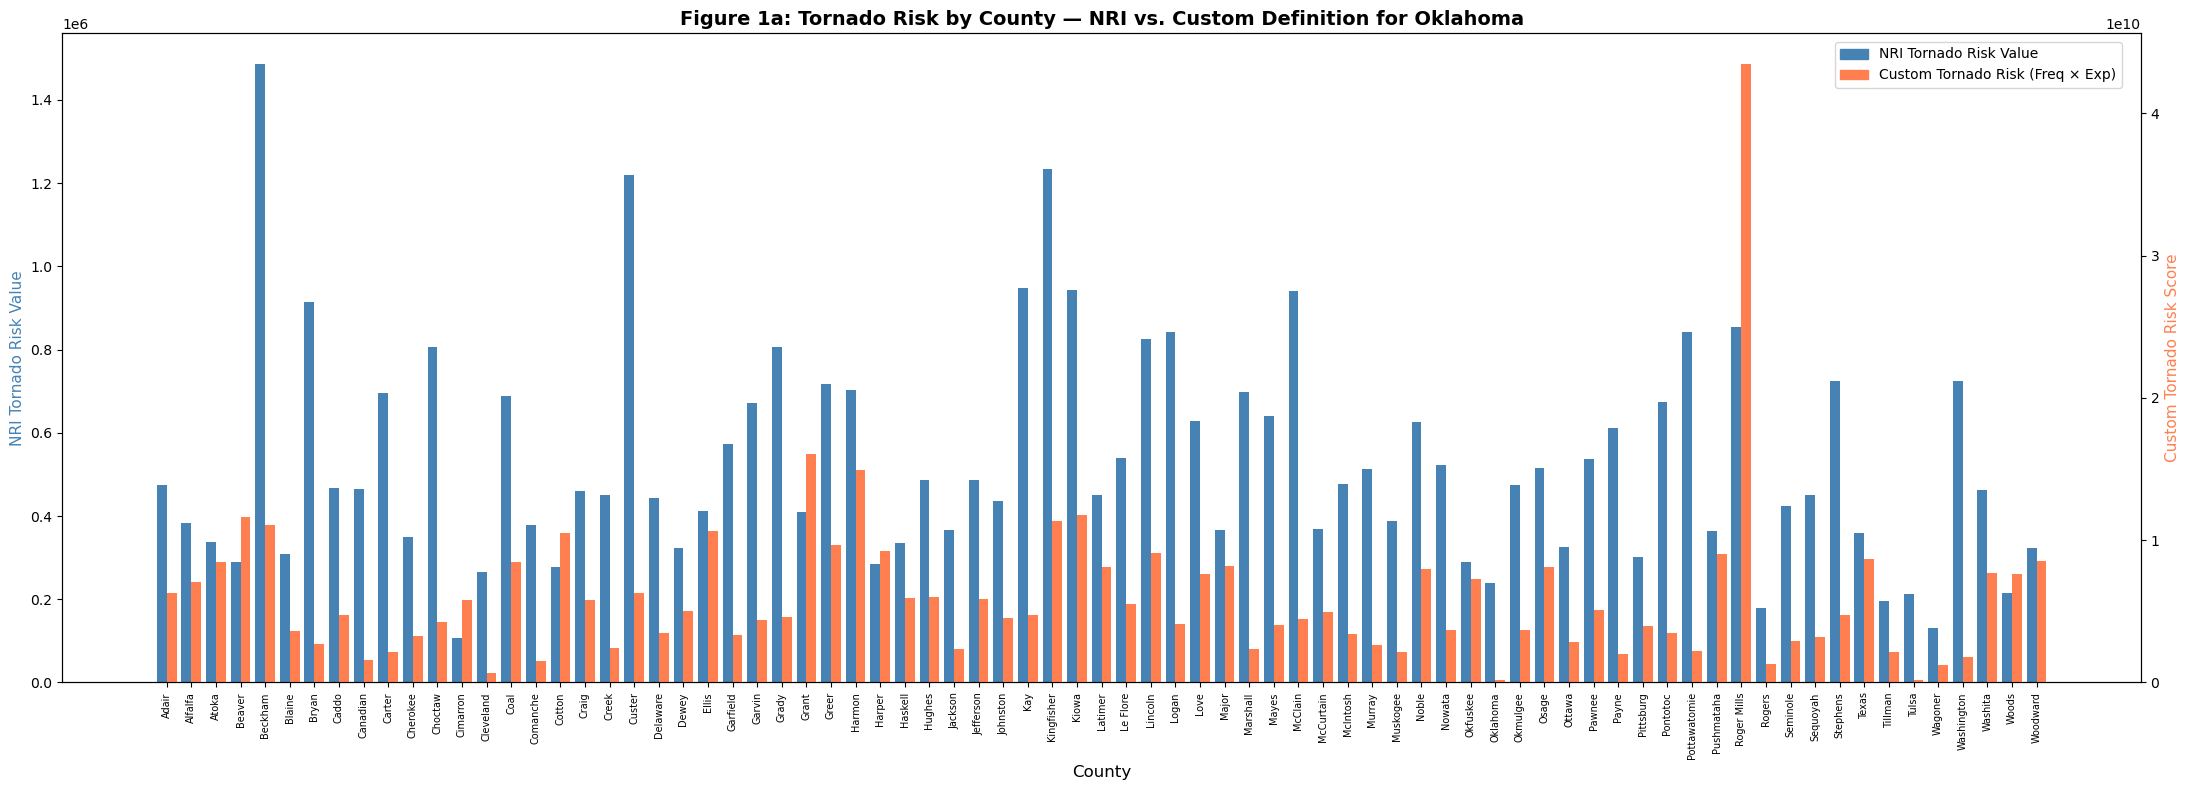

In [49]:
#Group Oklahoma data by county
ok_grouped = ok_complete.groupby('COUNTY').agg(
    nri_tornado=('TRND_RISKV', 'mean'),
    my_tornado=('tornado_risk', 'mean'),
    nri_winter=('WNTW_RISKV', 'mean'),
    my_winter=('winter_weather_risk', 'mean')
).reset_index()

#Figure 1a: Tornado Risk Comparison for Oklahoma
fig, ax1 = plt.subplots(figsize=(22, 8))
ax2 = ax1.twinx()

x = np.arange(len(ok_grouped))
ax1.bar(x - 0.2, ok_grouped['nri_tornado'], 0.4, color='steelblue', label='NRI Tornado Risk Value')
ax2.bar(x + 0.2, ok_grouped['my_tornado'], 0.4, color='coral', label='Custom Tornado Risk (Freq × Exp)')

ax1.set_xticks(x)
ax1.set_xticklabels(ok_grouped['COUNTY'], rotation=90, fontsize=7)
ax1.set_xlabel('County', fontsize=12)
ax1.set_ylabel('NRI Tornado Risk Value', color='steelblue', fontsize=11)
ax2.set_ylabel('Custom Tornado Risk Score', color='coral', fontsize=11)
ax1.tick_params(axis='x', rotation=90)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['steelblue','coral']]
fig.legend(handles, ['NRI Tornado Risk Value', 'Custom Tornado Risk (Freq × Exp)'],
           loc='upper right', bbox_to_anchor=(0.97, 0.95))

plt.title('Figure 1a: Tornado Risk by County — NRI vs. Custom Definition for Oklahoma',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure 1a: Tornado Risk by County — NRI vs. Custom Definition for Oklahoma.png", dpi = 300, bbox_inches = "tight")
plt.show()

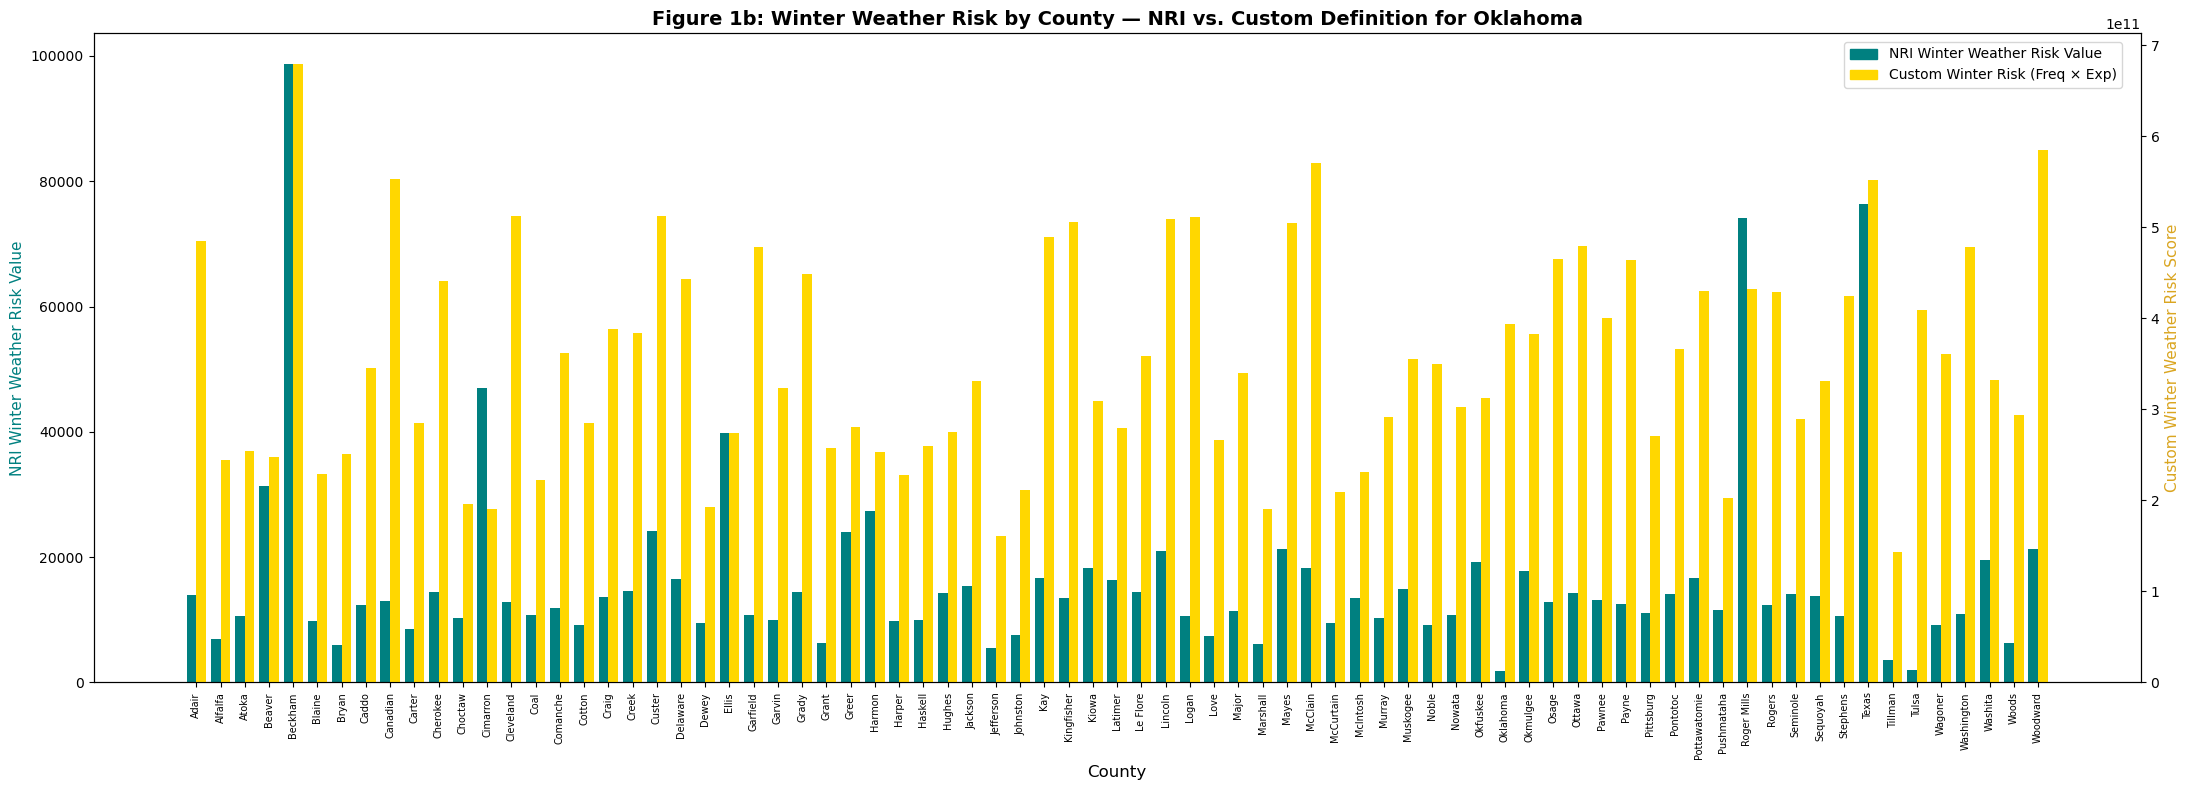

In [50]:
#Figure 1b: Winter Weather Risk Comparison for Oklahoma
fig, ax1 = plt.subplots(figsize=(22, 8))
ax2 = ax1.twinx()

x = np.arange(len(ok_grouped))
ax1.bar(x - 0.2, ok_grouped['nri_winter'], 0.4, color='teal', label='NRI Winter Weather Risk Value')
ax2.bar(x + 0.2, ok_grouped['my_winter'], 0.4, color='gold', label='Custom Winter Risk (Freq × Exp)')

ax1.set_xticks(x)
ax1.set_xticklabels(ok_grouped['COUNTY'], rotation=90, fontsize=7)
ax1.set_xlabel('County', fontsize=12)
ax1.set_ylabel('NRI Winter Weather Risk Value', color='teal', fontsize=11)
ax2.set_ylabel('Custom Winter Weather Risk Score', color='goldenrod', fontsize=11)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['teal','gold']]
fig.legend(handles, ['NRI Winter Weather Risk Value', 'Custom Winter Risk (Freq × Exp)'],
           loc='upper right', bbox_to_anchor=(0.97, 0.95))

plt.title('Figure 1b: Winter Weather Risk by County — NRI vs. Custom Definition for Oklahoma',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure 1b: Winter Weather Risk by County — NRI vs. Custom Definition for Oklahoma.png", dpi = 300, bbox_inches = "tight")
plt.show()

### Figure 2 — Mean Risk by County - Oregon: NRI vs. Custom Definition

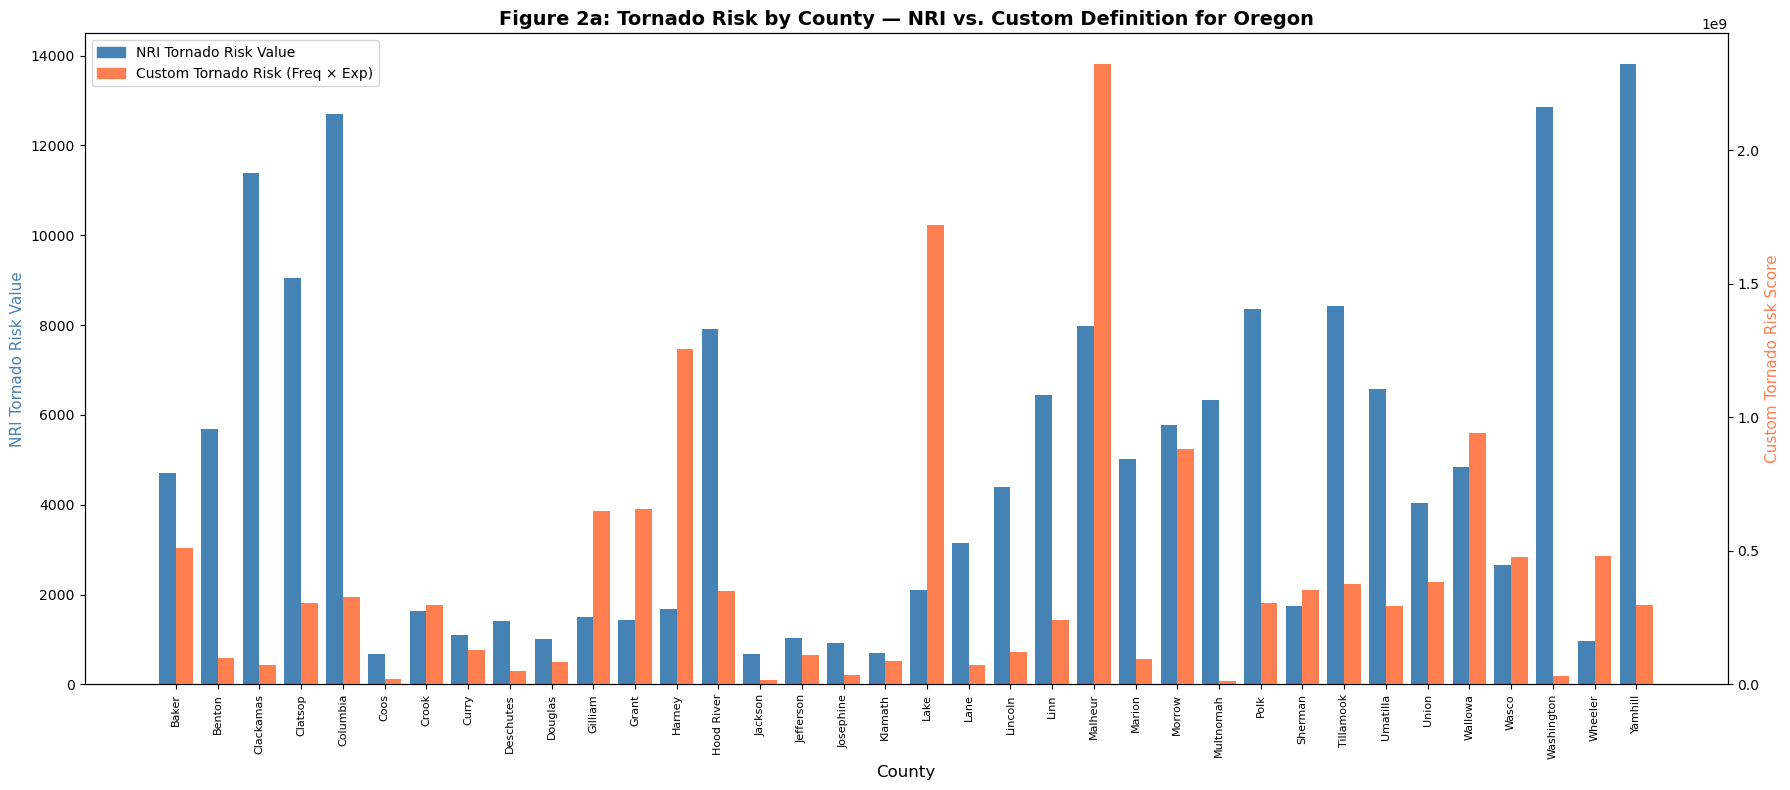

In [51]:
#Group Oregon data by county
or_grouped = or_complete.groupby('COUNTY').agg(
    nri_tornado=('TRND_RISKV', 'mean'),
    my_tornado=('tornado_risk', 'mean'),
    nri_winter=('WNTW_RISKV', 'mean'),
    my_winter=('winter_weather_risk', 'mean')
).reset_index()

#Figure 2a: Tornado Risk Comparison for Oregon
fig, ax1 = plt.subplots(figsize=(18, 8))
ax2 = ax1.twinx()

x = np.arange(len(or_grouped))
ax1.bar(x - 0.2, or_grouped['nri_tornado'], 0.4, color='steelblue', label='NRI Tornado Risk Value')
ax2.bar(x + 0.2, or_grouped['my_tornado'], 0.4, color='coral', label='Custom Tornado Risk (Freq × Exp)')

ax1.set_xticks(x)
ax1.set_xticklabels(or_grouped['COUNTY'], rotation=90, fontsize=8)
ax1.set_xlabel('County', fontsize=12)
ax1.set_ylabel('NRI Tornado Risk Value', color='steelblue', fontsize=11)
ax2.set_ylabel('Custom Tornado Risk Score', color='coral', fontsize=11)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['steelblue','coral']]
ax1.legend(handles, ['NRI Tornado Risk Value', 'Custom Tornado Risk (Freq × Exp)'],
           loc='upper left')

plt.title('Figure 2a: Tornado Risk by County — NRI vs. Custom Definition for Oregon',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure 2a: Tornado Risk by County — NRI vs. Custom Definition for Oregon.png", dpi = 300, bbox_inches = "tight")
plt.show()

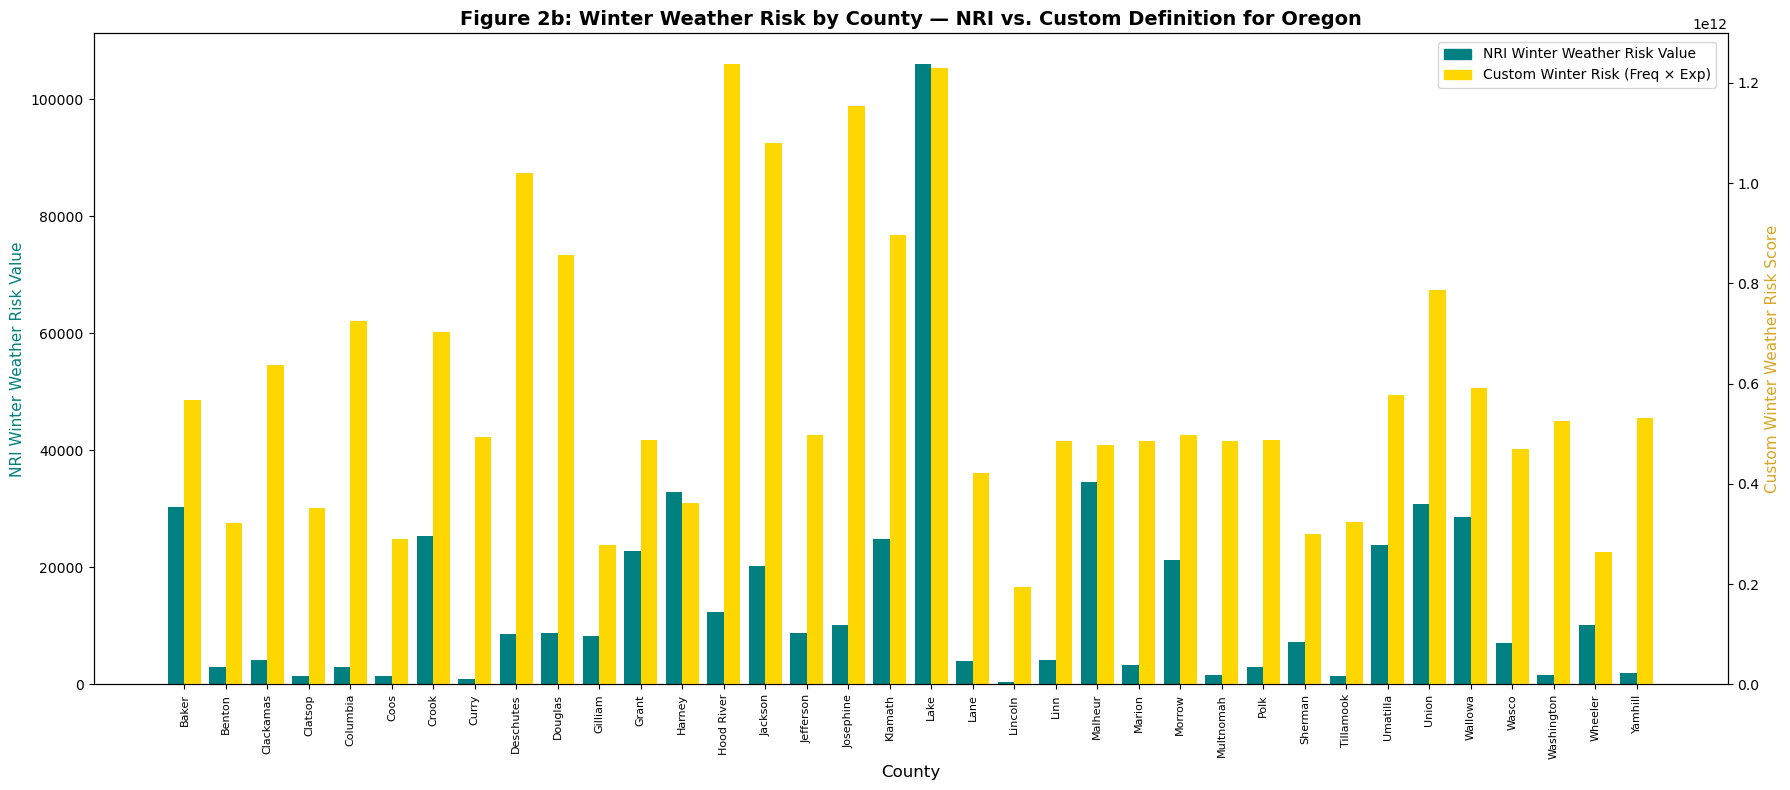

In [52]:
#Figure 2b: Winter Weather Risk Comparison for Oregon
fig, ax1 = plt.subplots(figsize=(18, 8))
ax2 = ax1.twinx()

x = np.arange(len(or_grouped))
ax1.bar(x - 0.2, or_grouped['nri_winter'], 0.4, color='teal', label='NRI Winter Weather Risk Value')
ax2.bar(x + 0.2, or_grouped['my_winter'], 0.4, color='gold', label='Custom Winter Risk (Freq × Exp)')

ax1.set_xticks(x)
ax1.set_xticklabels(or_grouped['COUNTY'], rotation=90, fontsize=8)
ax1.set_xlabel('County', fontsize=12)
ax1.set_ylabel('NRI Winter Weather Risk Value', color='teal', fontsize=11)
ax2.set_ylabel('Custom Winter Weather Risk Score', color='goldenrod', fontsize=11)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['teal','gold']]
fig.legend(handles, ['NRI Winter Weather Risk Value', 'Custom Winter Risk (Freq × Exp)'],
           loc='upper right', bbox_to_anchor=(0.96, 0.95))

plt.title('Figure 2b: Winter Weather Risk by County — NRI vs. Custom Definition for Oregon',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure 2b: Winter Weather Risk by County — NRI vs. Custom Definition for Oregon.png", dpi = 300, bbox_inches = "tight")
plt.show()

### Table 1 — Summary Statistics by State

A summary table comparing NRI risk values and custom risk scores across both states 
for both hazards.

In [30]:
#Summary Statistics Table
summary_rows = []

for state_name, df in [('Oklahoma', ok_complete), ('Oregon', or_complete)]:
    for hazard, nri_col, my_col in [
        ('Tornado', 'TRND_RISKV', 'tornado_risk'),
        ('Winter Weather', 'WNTW_RISKV', 'winter_weather_risk')
    ]:
        summary_rows.append({
            'State': state_name,
            'Hazard': hazard,
            'NRI Risk Mean': round(df[nri_col].mean(), 2),
            'NRI Risk Median': round(df[nri_col].median(), 2),
            'NRI Risk Max': round(df[nri_col].max(), 2),
            'Custom Risk Mean': round(df[my_col].mean(), 4),
            'Custom Risk Median': round(df[my_col].median(), 4),
            'Custom Risk Max': round(df[my_col].max(), 4),
        })

summary_table = pd.DataFrame(summary_rows)
print("Table 1: Risk Summary Statistics by State and Hazard")
print(summary_table.to_string(index=False))

Table 1: Risk Summary Statistics by State and Hazard
   State         Hazard  NRI Risk Mean  NRI Risk Median  NRI Risk Max  Custom Risk Mean  Custom Risk Median  Custom Risk Max
Oklahoma        Tornado      250391.86        216450.18    2186144.36      3.843446e+08        6.052945e+07     4.344120e+10
Oklahoma Winter Weather        3260.50          1950.89     130257.81      4.046328e+11        3.880574e+11     1.459518e+12
  Oregon        Tornado        7335.93          6172.29      26713.74      4.357242e+07        4.541336e+06     1.762102e+10
  Oregon Winter Weather        3330.92          1926.13     120024.92      5.386884e+11        4.827709e+11     2.381752e+12


---
## Section 7: GeoPandas Maps

We load the NRI Census Tract shapefile, clean the projection, and produce 8 maps:
- 4 maps for Oklahoma (NRI tornado, NRI winter weather, custom tornado, custom winter weather)
- 4 maps for Oregon (same as above)

In [38]:
#Load the NRI Shapefile
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

#Set and convert CRS
tracts_clean = tracts.set_crs(epsg=4326, inplace=True, allow_override=True)
tracts_clean = tracts_clean.to_crs(epsg=4326)

#Replace -9999 placeholders with NaN
tracts_clean = tracts_clean.replace(-9999, np.nan)

#Convert Projection
tracts_clean.crs = "EPSG:3857"
tracts_clean = tracts_clean.to_crs(epsg=4326)

print("Shapefile loaded and projected successfully.")
print("CRS:", tracts_clean.crs)
print("Shape:", tracts_clean.shape)

Shapefile loaded and projected successfully.
CRS: EPSG:4326
Shape: (85154, 469)


In [39]:
#Add custom risk columns to the shapefile GeoDataFrame
tracts_clean['tornado_risk'] = tracts_clean['TRND_AFREQ'] * tracts_clean['TRND_EXPT']
tracts_clean['winter_weather_risk'] = tracts_clean['WNTW_AFREQ'] * tracts_clean['WNTW_EXPT']

print("Custom risk columns added to shapefile.")

Custom risk columns added to shapefile.


### Oklahoma Maps

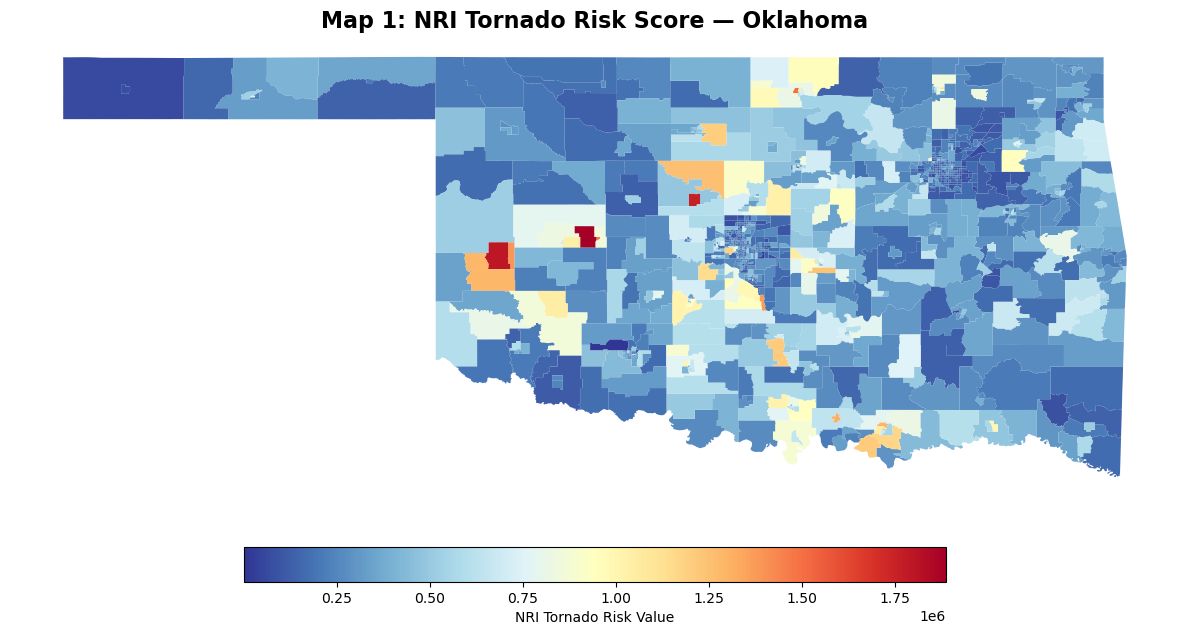

In [53]:
#Map 1: Oklahoma — NRI Tornado Risk
state_name = "Oklahoma"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="TRND_RISKV", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "NRI Tornado Risk Value", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Map 1: NRI Tornado Risk Score — Oklahoma", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Map 1: NRI Tornado Risk Score — Oklahoma.png", dpi = 300, bbox_inches = "tight")
plt.show()

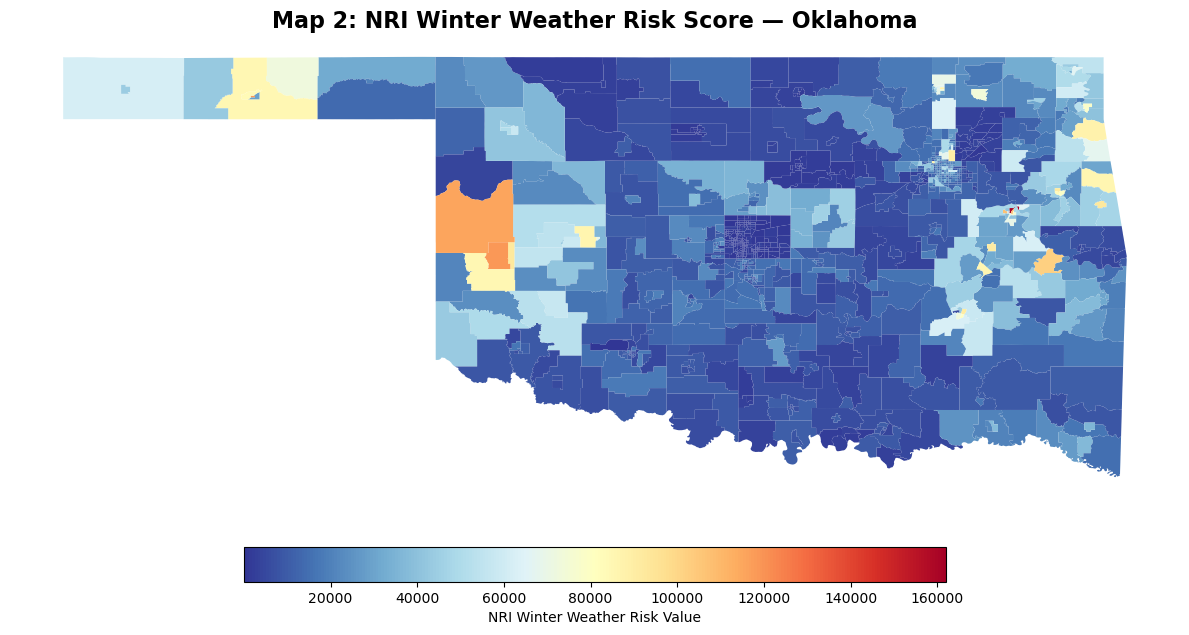

In [54]:
#Map 2: Oklahoma — NRI Winter Weather Risk
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="WNTW_RISKV", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "NRI Winter Weather Risk Value", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Map 2: NRI Winter Weather Risk Score — Oklahoma", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Map 2: NRI Winter Weather Risk Score — Oklahoma.png", dpi = 300, bbox_inches = "tight")
plt.show()

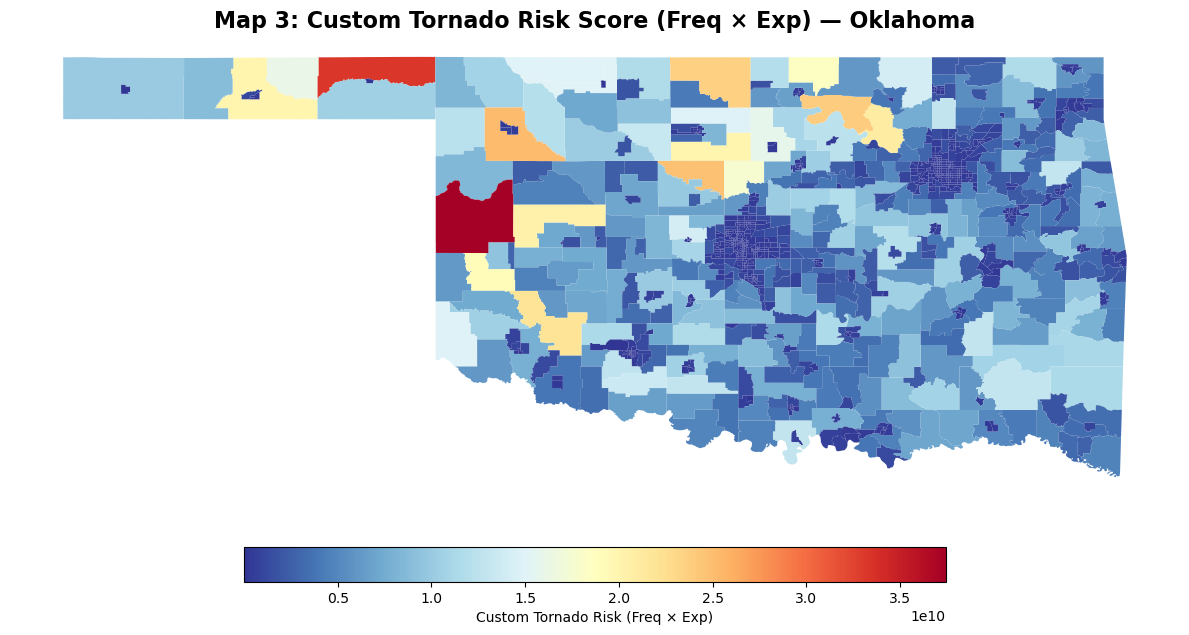

In [55]:
#Map 3: Oklahoma — Custom Tornado Risk (Frequency × Exposure)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="tornado_risk", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "Custom Tornado Risk (Freq × Exp)", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Map 3: Custom Tornado Risk Score (Freq × Exp) — Oklahoma", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Map 3: Custom Tornado Risk Score (Freq × Exp) — Oklahoma.png", dpi = 300, bbox_inches = "tight")
plt.show()

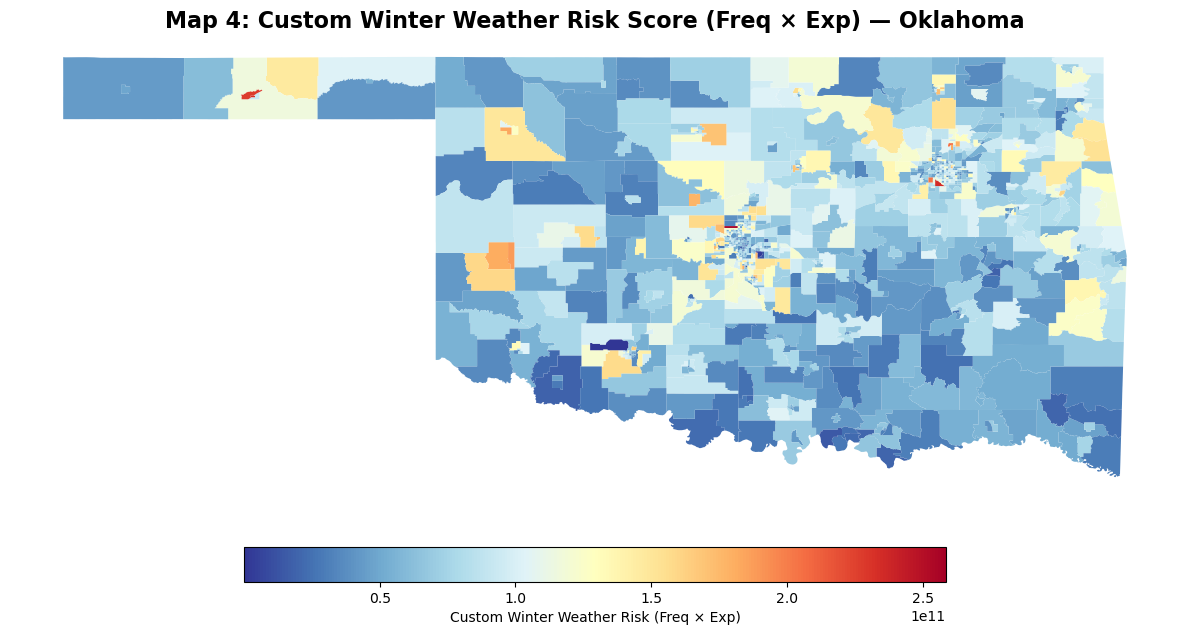

In [56]:
#Map 4: Oklahoma — Custom Winter Weather Risk (Frequency × Exposure)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(column="winter_weather_risk", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
               legend=True,
               legend_kwds={"label": "Custom Winter Weather Risk (Freq × Exp)", "orientation": "horizontal",
                            "shrink": 0.6, "pad": 0.05},
               missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Map 4: Custom Winter Weather Risk Score (Freq × Exp) — Oklahoma", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Map 4: Custom Winter Weather Risk Score (Freq × Exp) — Oklahoma.png", dpi = 300, bbox_inches = "tight")
plt.show()

### Oregon Maps

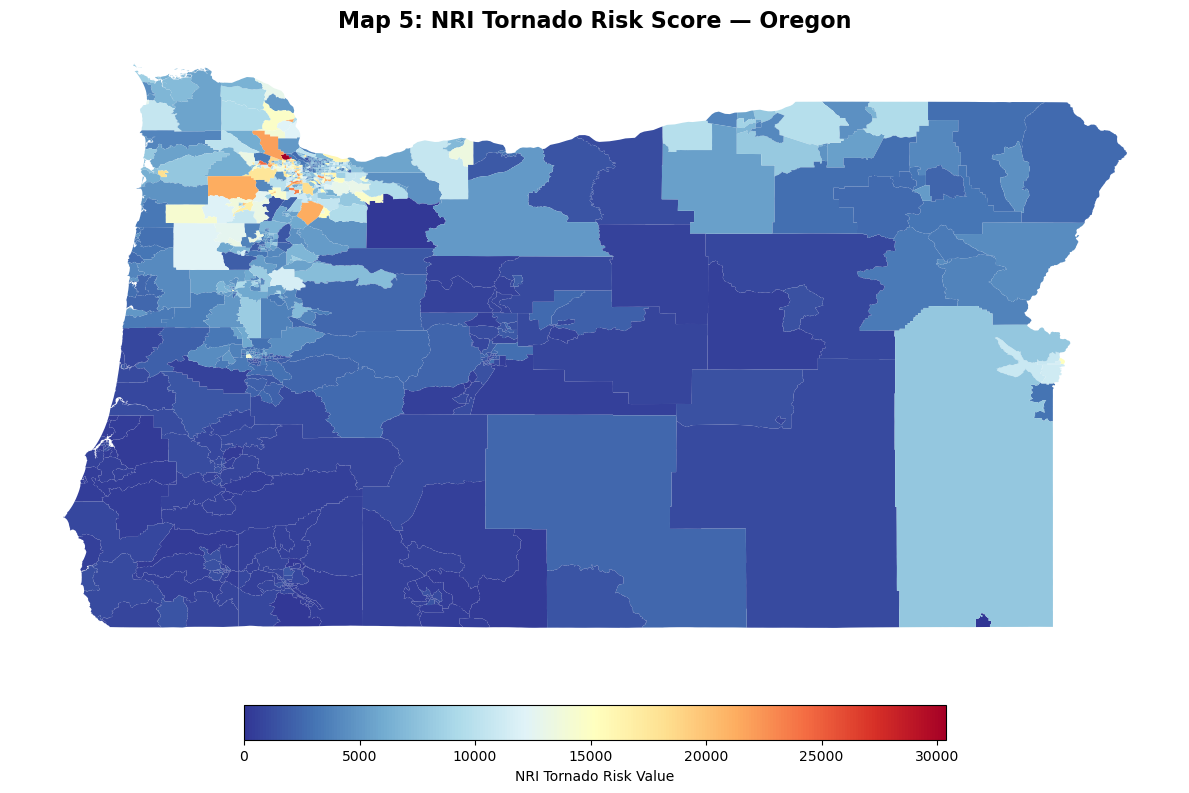

In [57]:
#Map 5: Oregon — NRI Tornado Risk
state_name = "Oregon"
state_map_or = tracts_clean[tracts_clean["STATE"] == state_name]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map_or.plot(column="TRND_RISKV", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
                  legend=True,
                  legend_kwds={"label": "NRI Tornado Risk Value", "orientation": "horizontal",
                               "shrink": 0.6, "pad": 0.05},
                  missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Map 5: NRI Tornado Risk Score — Oregon", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Map 5: NRI Tornado Risk Score — Oregon.png", dpi = 300, bbox_inches = "tight")
plt.show()

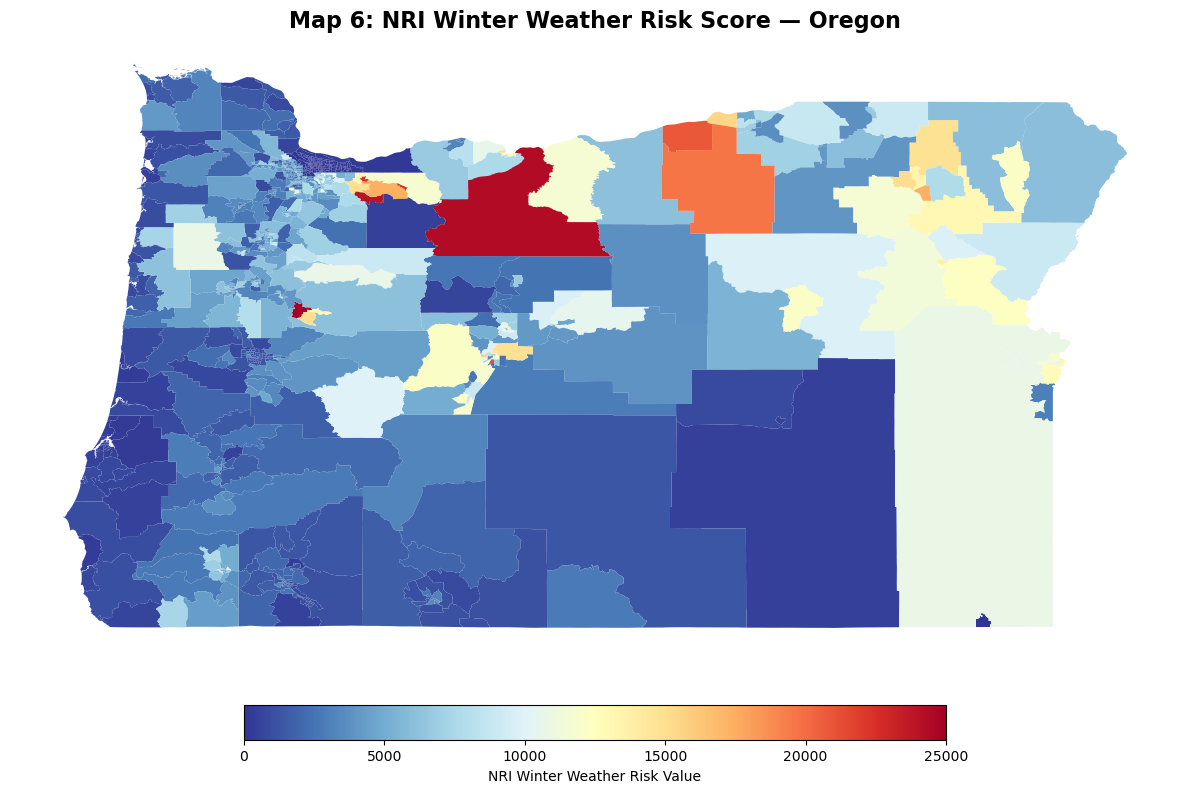

In [58]:
#Map 6: Oregon — NRI Winter Weather Risk
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map_or.plot(column="WNTW_RISKV", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
                  legend=True,
                  legend_kwds={"label": "NRI Winter Weather Risk Value", "orientation": "horizontal",
                               "shrink": 0.6, "pad": 0.05},
                  missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Map 6: NRI Winter Weather Risk Score — Oregon", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Map 6: NRI Winter Weather Risk Score — Oregon.png", dpi = 300, bbox_inches = "tight")
plt.show()

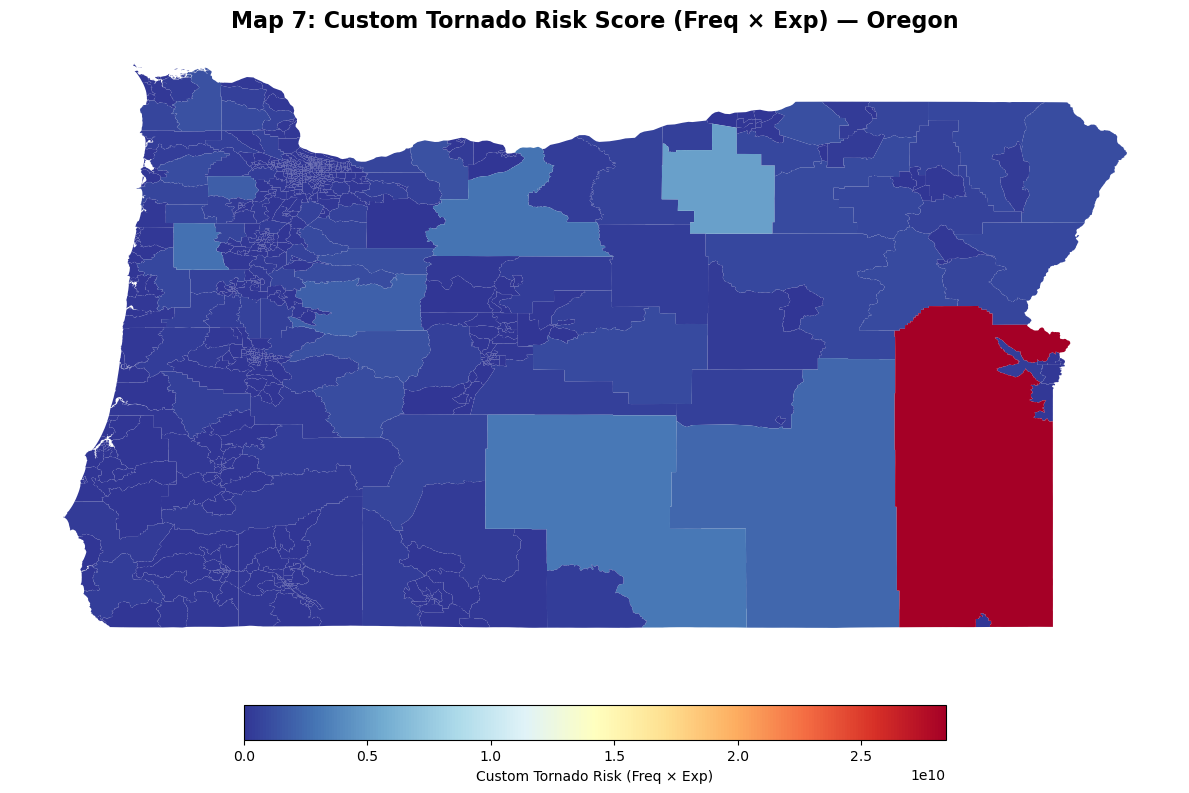

In [59]:
#Map 7: Oregon — Custom Tornado Risk (Frequency × Exposure)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map_or.plot(column="tornado_risk", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
                  legend=True,
                  legend_kwds={"label": "Custom Tornado Risk (Freq × Exp)", "orientation": "horizontal",
                               "shrink": 0.6, "pad": 0.05},
                  missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Map 7: Custom Tornado Risk Score (Freq × Exp) — Oregon", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Map 7: Custom Tornado Risk Score (Freq × Exp) — Oregon.png", dpi = 300, bbox_inches = "tight")
plt.show()

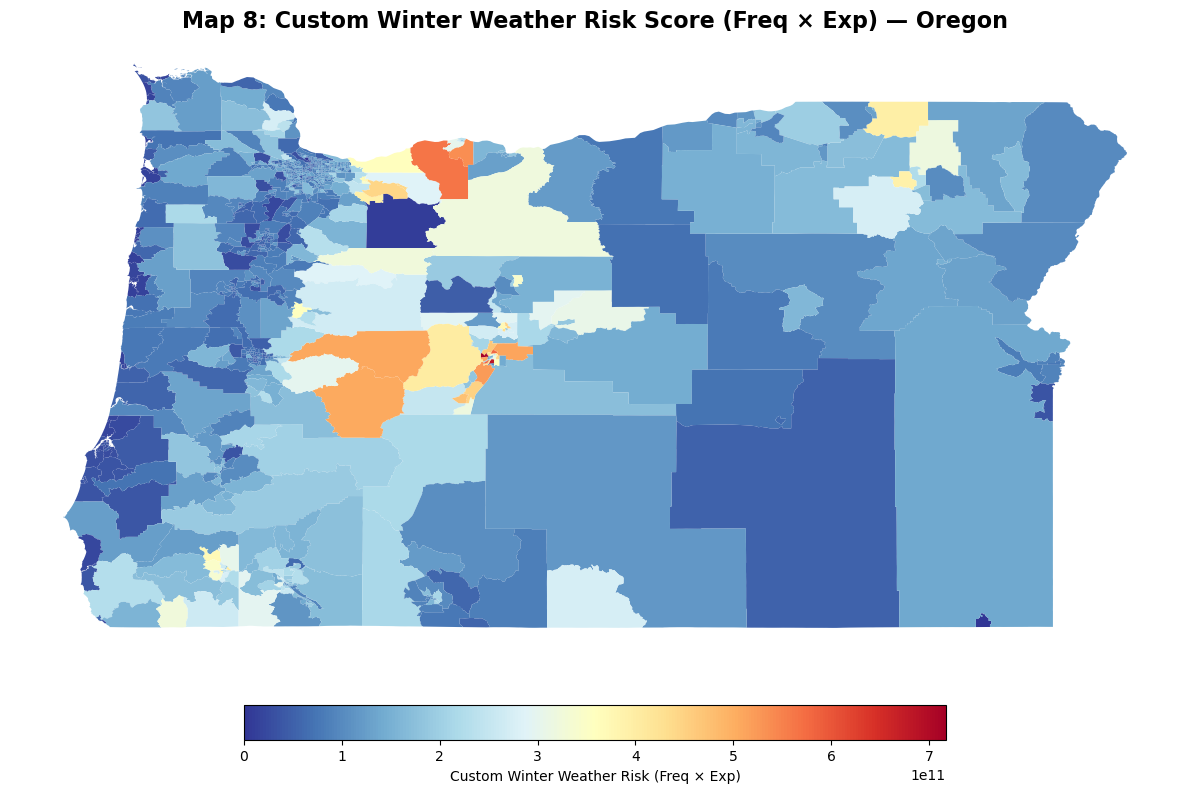

In [60]:
#Map 8: Oregon — Custom Winter Weather Risk (Frequency × Exposure)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map_or.plot(column="winter_weather_risk", cmap="RdYlBu_r", aspect=1, linewidth=0.0, ax=ax,
                  legend=True,
                  legend_kwds={"label": "Custom Winter Weather Risk (Freq × Exp)", "orientation": "horizontal",
                               "shrink": 0.6, "pad": 0.05},
                  missing_kwds={"color": "lightgrey", "label": "No Data"})
ax.set_title("Map 8: Custom Winter Weather Risk Score (Freq × Exp) — Oregon", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Map 8: Custom Winter Weather Risk Score (Freq × Exp) — Oregon.png", dpi = 300, bbox_inches = "tight")
plt.show()

---
## End of Analysis